# EDA: theme-park queue data

Real queue data from **PortAventura World** (Spain) and **Tivoli Gardens** (Copenhagen).
Goal: understand the data before building the wait-time model, and check the assumptions in `prepare_data.py`.

Run the cells top to bottom. Each section ends with a question to answer from the result.

In [2]:
   %pip install pandas matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 5.7 MB/s eta 0:00:02
   --- ------------------------------------ 0.8/9.8 MB 2.2 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.8 MB 4.1 MB/s eta 0:00:02
   ----------------------------- ---------- 7.3/9.8 MB 9.6 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 10.9 MB/s  0:00:00
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --------------- ------------------------ 3.7/9.5 MB 19.8 MB/s eta 0:00:01
   --------------- ------------------------ 3.7/9.5 MB 19.8 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 15.9 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 14.4 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# works whether the notebook runs from ml/ or from the repo root
DATA = Path("data") if Path("data/waiting_times.csv").exists() else Path("ml/data")

# chart style: thin marks, quiet axes
BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#888", "axes.grid": True, "grid.color": "#e5e5e5", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "lines.linewidth": 2, "font.size": 10,
})
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
print("data folder:", DATA.resolve())

data folder: C:\Users\ahmad\Downloads\expo-hackathon-starter\expo-hackathon\ml\data


## 1. Load the data

In [3]:
cols = ["WORK_DATE", "DEB_TIME", "ENTITY_DESCRIPTION_SHORT", "WAIT_TIME_MAX", "GUEST_CARRIED",
        "CAPACITY", "ADJUST_CAPACITY", "OPEN_TIME", "UP_TIME", "DOWNTIME"]
waits = pd.read_csv(DATA / "waiting_times.csv", usecols=cols)
waits["DEB_TIME"] = pd.to_datetime(waits["DEB_TIME"])
waits["WORK_DATE"] = pd.to_datetime(waits["WORK_DATE"])
waits = waits.rename(columns={"ENTITY_DESCRIPTION_SHORT": "ATTRACTION"})

link = pd.read_csv(DATA / "link_attraction_park.csv", sep=";")
attendance = pd.read_csv(DATA / "attendance.csv", parse_dates=["USAGE_DATE"])
waits = waits.merge(link, on="ATTRACTION", how="left")

print(f"waiting_times: {len(waits):,} rows, {waits.memory_usage(deep=True).sum() / 1e9:.2f} GB in memory")
print(f"attendance:    {len(attendance):,} rows")
waits.head()

waiting_times: 3,509,324 rows, 0.69 GB in memory
attendance:    2,367 rows


,WORK_DATE,DEB_TIME,ATTRACTION,WAIT_TIME_MAX,GUEST_CARRIED,CAPACITY,ADJUST_CAPACITY,OPEN_TIME,UP_TIME,DOWNTIME,PARK
0,2018-01-01,2018-01-01 21:00:00,Roller Coaster,0,0.00,0.00,0.00,0,0,0,PortAventura World
1,2018-01-01,2018-01-01 19:30:00,Bumper Cars,5,148.00,254.75,254.75,15,15,0,PortAventura World
2,2018-01-01,2018-01-01 22:30:00,Rapids Ride,0,0.00,0.00,0.00,0,0,0,PortAventura World
3,2018-01-01,2018-01-01 12:45:00,Crazy Dance,5,46.00,250.00,250.00,15,15,0,PortAventura World
4,2018-01-01,2018-01-01 17:00:00,Skyway,5,92.00,211.50,198.25,15,15,0,Tivoli Gardens


## 2. Overview — what's in it?

In [4]:
print("dates:", waits["WORK_DATE"].min().date(), "to", waits["WORK_DATE"].max().date())
print("days with data:", waits["WORK_DATE"].nunique())
print("\nrides per park:")
print(waits.groupby("PARK", dropna=False)["ATTRACTION"].nunique())
print("\nrides with no park in link file:", waits.loc[waits["PARK"].isna(), "ATTRACTION"].unique())
print("\nmissing values per column (%):")
print((waits.isna().mean() * 100).round(2))

dates: 2018-01-01 to 2022-08-18
days with data: 1691

rides per park:
PARK
PortAventura World    26
Tivoli Gardens        13
Name: ATTRACTION, dtype: int64

rides with no park in link file: <StringArray>
[]
Length: 0, dtype: str

missing values per column (%):
WORK_DATE         0.00
DEB_TIME          0.00
ATTRACTION        0.00
WAIT_TIME_MAX     0.00
GUEST_CARRIED     0.00
CAPACITY          0.00
ADJUST_CAPACITY   0.00
OPEN_TIME         0.00
UP_TIME           0.00
DOWNTIME          0.00
PARK              0.00
dtype: float64


In [5]:
print(waits.dtypes)
print("\nnon-numeric columns:", list(waits.select_dtypes(exclude="number").columns))

WORK_DATE          datetime64[us]
DEB_TIME           datetime64[us]
ATTRACTION                    str
WAIT_TIME_MAX               int64
GUEST_CARRIED             float64
CAPACITY                  float64
ADJUST_CAPACITY           float64
OPEN_TIME                   int64
UP_TIME                     int64
DOWNTIME                    int64
PARK                          str
dtype: object

non-numeric columns: ['WORK_DATE', 'DEB_TIME', 'ATTRACTION', 'PARK']


**Question:** how many rides and years do we really have? Any rides missing from the link file?

## 3. Closed slots — how much of the data is "ride not running"?

In [6]:
closed = (waits["OPEN_TIME"] == 0) | (waits["CAPACITY"] == 0)
print(f"closed slots: {closed.mean():.1%} of rows")
print(f"closed slots that still show a wait > 0: {(closed & (waits['WAIT_TIME_MAX'] > 0)).sum():,}")
print(f"open slots with some downtime: {((~closed) & (waits['DOWNTIME'] > 0)).mean():.1%}")

open_ = waits[~closed].copy()
print(f"\nopen slots kept for analysis: {len(open_):,}")

closed slots: 46.4% of rows
closed slots that still show a wait > 0: 19,206
open slots with some downtime: 2.6%

open slots kept for analysis: 1,880,430


**Question:** is dropping closed slots safe? If many closed slots still have waits, the rule needs changing.

In [ ]:

odd = waits[closed & (waits["WAIT_TIME_MAX"] > 0)]
print("open_time = 0:", (odd["OPEN_TIME"] == 0).sum())
print("capacity = 0:", (odd["CAPACITY"] == 0).sum())
print("both = 0:   ", ((odd["OPEN_TIME"] == 0) & (odd["CAPACITY"] == 0)).sum())
print("\nwait values:")
print(odd["WAIT_TIME_MAX"].describe().round(1))
odd.head(10)

open_time = 0: 18448
capacity = 0: 19206
both = 0:    18448

wait values:
count   19,206.00
mean        21.10
std         23.00
min          5.00
25%          5.00
50%         10.00
75%         25.00
max        240.00
Name: WAIT_TIME_MAX, dtype: float64


,WORK_DATE,DEB_TIME,ATTRACTION,WAIT_TIME_MAX,GUEST_CARRIED,CAPACITY,ADJUST_CAPACITY,OPEN_TIME,UP_TIME,DOWNTIME,PARK
5,2018-01-01,2018-01-01 18:15:00,Free Fall,50,0.00,0.00,0.00,0,0,0,PortAventura World
18,2018-01-01,2018-01-01 21:30:00,Water Ride,15,0.00,0.00,0.00,0,0,0,PortAventura World
61,2018-01-01,2018-01-01 22:00:00,Swing Ride,25,0.00,0.00,0.00,0,0,0,PortAventura World
201,2018-01-01,2018-01-01 21:15:00,Water Ride,15,0.00,0.00,0.00,0,0,0,PortAventura World
211,2018-01-01,2018-01-01 21:00:00,Haunted House,10,0.00,0.00,0.00,0,0,0,PortAventura World
217,2018-01-01,2018-01-01 22:00:00,Drop Tower,10,0.00,0.00,0.00,0,0,0,PortAventura World
263,2018-01-01,2018-01-01 22:00:00,Crazy Dance,5,0.00,0.00,0.00,0,0,0,PortAventura World
298,2018-01-01,2018-01-01 19:15:00,Skyway,5,0.00,0.00,0.00,0,0,0,Tivoli Gardens
313,2018-01-01,2018-01-01 19:15:00,Sling Shot,5,0.00,0.00,0.00,0,0,0,Tivoli Gardens
318,2018-01-01,2018-01-01 16:30:00,Oz Theatre,10,0.00,0.00,0.00,0,0,0,PortAventura World


## 4. Wait time distribution

count   1,880,430.00
mean           25.10
std            23.00
min             0.00
50%            15.00
90%            55.00
99%           100.00
max           300.00
Name: WAIT_TIME_MAX, dtype: float64

zero waits: 3.8%   waits over 120 min: 0.18%   over 300: 0


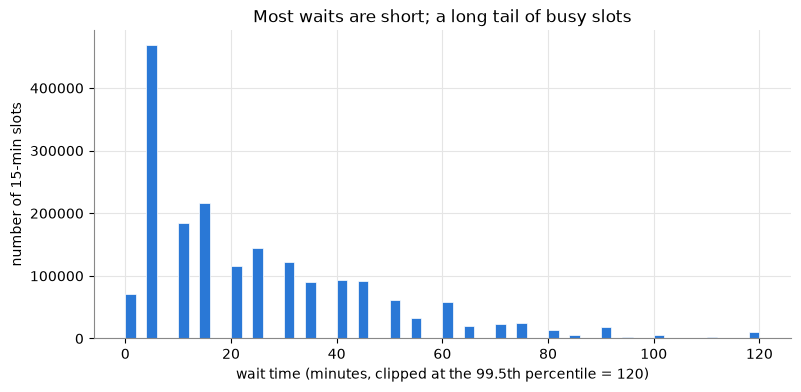

In [8]:
w = open_["WAIT_TIME_MAX"]
print(w.describe(percentiles=[.5, .9, .99]).round(1))
print(f"\nzero waits: {(w == 0).mean():.1%}   waits over 120 min: {(w > 120).mean():.2%}   over 300: {(w > 300).sum():,}")

cap = w.quantile(0.995)
fig, ax = plt.subplots()
ax.hist(w.clip(upper=cap), bins=60, color=BLUE, edgecolor="white", linewidth=0.5)
ax.set_title("Most waits are short; a long tail of busy slots")
ax.set_xlabel(f"wait time (minutes, clipped at the 99.5th percentile = {cap:.0f})")
ax.set_ylabel("number of 15-min slots")
plt.show()

##the above chart shows how much does each wait time repeats


**Question:** is the 300-minute cap in `prepare_data.py` sensible? How many zeros — are they real or missing data?

## 5. Patterns over time

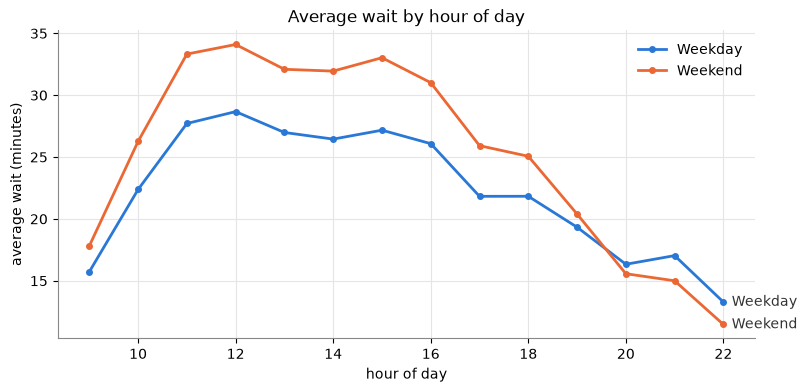

weekend,False,True
hour,,
9,15.70,17.80
10,22.40,26.30
11,27.70,33.30
12,28.70,34.10
13,27.00,32.10
14,26.50,31.90
15,27.20,33.00
16,26.10,31.00
17,21.80,25.90


In [9]:
open_["hour"] = open_["DEB_TIME"].dt.hour
open_["weekend"] = open_["DEB_TIME"].dt.dayofweek >= 5
open_["month"] = open_["DEB_TIME"].dt.month

by_hour = open_.groupby(["hour", "weekend"])["WAIT_TIME_MAX"].mean().unstack()
fig, ax = plt.subplots()
ax.plot(by_hour.index, by_hour[False], color=BLUE, marker="o", markersize=4, label="Weekday")
ax.plot(by_hour.index, by_hour[True], color=ORANGE, marker="o", markersize=4, label="Weekend")
for col, c in [(False, BLUE), (True, ORANGE)]:
    s = by_hour[col].dropna()
    ax.annotate("Weekend" if col else "Weekday", (s.index[-1], s.iloc[-1]), xytext=(6, 0),
                textcoords="offset points", color="#333", va="center")
ax.set_title("Average wait by hour of day")
ax.set_xlabel("hour of day"); ax.set_ylabel("average wait (minutes)")
ax.legend(frameon=False)
plt.show()
by_hour.round(1)

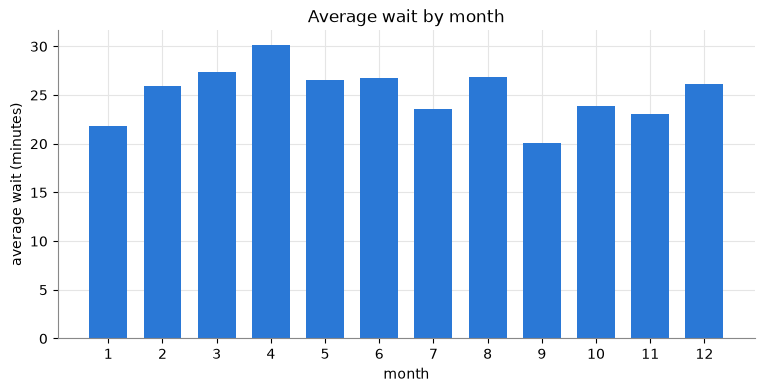

In [10]:
by_month = open_.groupby("month")["WAIT_TIME_MAX"].mean()
fig, ax = plt.subplots()
ax.bar(by_month.index, by_month.values, color=BLUE, width=0.7)
ax.set_xticks(range(1, 13))
ax.set_title("Average wait by month")
ax.set_xlabel("month"); ax.set_ylabel("average wait (minutes)")
plt.show()

**Question:** when are the peaks? Do they match what we saw at Osaka and Dubai (evenings, weekends, end-of-season)?

## 6. Crowd size vs wait — is attendance a strong feature?

attendance dates: 2018-06-01 to 2022-07-26
days per park:
 PARK
PortAventura World    1182
Tivoli Gardens        1185
Name: WORK_DATE, dtype: int64

park-days with waits but NO attendance: 13.0%
PortAventura World: correlation attendance vs avg wait = 0.87
Tivoli Gardens: correlation attendance vs avg wait = 0.80


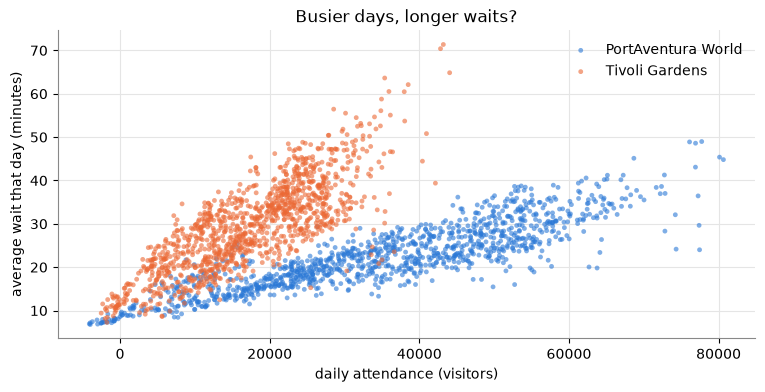

In [11]:
att = attendance.rename(columns={"USAGE_DATE": "WORK_DATE", "FACILITY_NAME": "PARK"})
print("attendance dates:", att["WORK_DATE"].min().date(), "to", att["WORK_DATE"].max().date())
print("days per park:\n", att.groupby("PARK")["WORK_DATE"].nunique())

daily = open_.groupby(["WORK_DATE", "PARK"])["WAIT_TIME_MAX"].mean().reset_index(name="avg_wait")
daily = daily.merge(att, on=["WORK_DATE", "PARK"], how="left")
print(f"\npark-days with waits but NO attendance: {daily['attendance'].isna().mean():.1%}")

d = daily.dropna(subset=["attendance"])
fig, ax = plt.subplots()
for park, c in zip(sorted(d["PARK"].unique()), [BLUE, ORANGE]):
    s = d[d["PARK"] == park]
    ax.scatter(s["attendance"], s["avg_wait"], s=12, color=c, alpha=0.6, label=park, edgecolors="none")
    print(f"{park}: correlation attendance vs avg wait = {s['attendance'].corr(s['avg_wait']):.2f}")
ax.set_title("Busier days, longer waits?")
ax.set_xlabel("daily attendance (visitors)"); ax.set_ylabel("average wait that day (minutes)")
ax.legend(frameon=False)
plt.show()

**Question:** how strong is the link? And how many rows would `prepare_data.py` drop because attendance is missing?

In [12]:
neg = attendance[attendance["attendance"] <= 0]
print(len(neg), "days with zero or negative attendance")
neg.sort_values("attendance").head(10)

83 days with zero or negative attendance


,USAGE_DATE,FACILITY_NAME,attendance
1532,2021-02-04,PortAventura World,-9991
1546,2021-06-07,PortAventura World,-9990
1541,2021-06-01,PortAventura World,-9988
1543,2021-06-03,PortAventura World,-9988
1550,2021-06-13,PortAventura World,-9987
1545,2021-06-04,PortAventura World,-9985
1542,2021-06-02,PortAventura World,-9975
1547,2021-06-11,PortAventura World,-9962
1306,2020-07-10,PortAventura World,-9959
1552,2021-06-14,PortAventura World,-9955


##WE WILL NEED CLEANING HERE

## 7. How full the ride is vs wait

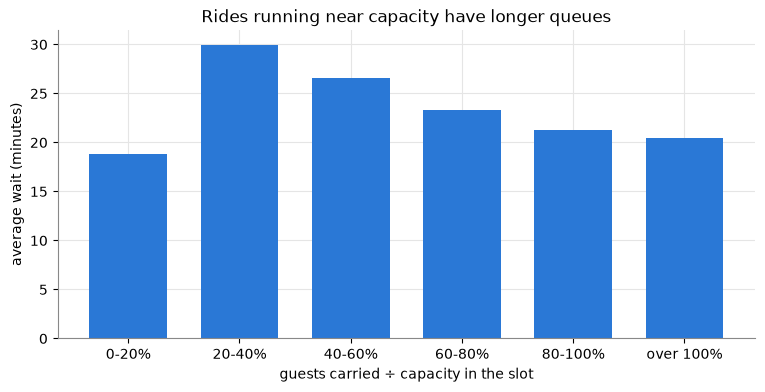

load_bin
0-20%       18.80
20-40%      29.90
40-60%      26.50
60-80%      23.30
80-100%     21.30
over 100%   20.40
Name: WAIT_TIME_MAX, dtype: float64

In [13]:
o = open_[open_["CAPACITY"] > 0].copy()
o["load_ratio"] = (o["GUEST_CARRIED"] / o["CAPACITY"]).clip(0, 1.5)
o["load_bin"] = pd.cut(o["load_ratio"], bins=[0, .2, .4, .6, .8, 1.0, 1.5], include_lowest=True,
                       labels=["0-20%", "20-40%", "40-60%", "60-80%", "80-100%", "over 100%"])
by_load = o.groupby("load_bin", observed=True)["WAIT_TIME_MAX"].mean()

fig, ax = plt.subplots()
ax.bar(by_load.index.astype(str), by_load.values, color=BLUE, width=0.7)
ax.set_title("Rides running near capacity have longer queues")
ax.set_xlabel("guests carried ÷ capacity in the slot"); ax.set_ylabel("average wait (minutes)")
plt.show()
by_load.round(1)

The chart above is a bit misleading

**Question:** does wait rise as the ride fills up? This is the Expo equivalent of *entries ÷ pavilion capacity*.

In [14]:
o["load_ratio"] = (o["GUEST_CARRIED"] / o["CAPACITY"]).clip(0, 1.5)
per_ride = o.groupby("ATTRACTION").apply(
    lambda g: g["load_ratio"].corr(g["WAIT_TIME_MAX"])
).sort_values()
print(per_ride.round(2))
print("\nmedian correlation across rides:", round(per_ride.median(), 2))

ATTRACTION
Swing Ride         -0.43
Log Flume          -0.36
Giant Wheel        -0.24
Scooby Doo         -0.23
Spiral Slide       -0.18
Crazy Bus          -0.12
Inverted Coaster   -0.09
Go-Karts           -0.08
Roller Coaster     -0.06
Monorail            0.01
Dizzy Dropper       0.02
Aeroplane Ride      0.05
Spinning Coaster    0.06
Water Ride          0.06
Free Fall           0.09
Haunted House       0.11
Zipline             0.11
Oz Theatre          0.12
Pirate Ship         0.13
Drop Tower          0.14
Superman Ride       0.14
Himalaya Ride       0.14
Vertical Drop       0.15
Tilt-A-Whirl        0.16
Rapids Ride         0.16
Circus Train        0.18
Crazy Dance         0.23
Reverse Bungee      0.24
Gondola             0.25
Merry Go Round      0.27
Kiddie Coaster      0.27
Giga Coaster        0.29
Sling Shot          0.31
Flying Coaster      0.34
Bumper Cars         0.37
Power Tower         0.39
Bungee Jump         0.40
Skyway              0.44
Top Spin            0.61
dtype: float64

# this indcates that how full is the ride (the pavilion in our case) dont indicate how much is the wait. u need to know how much people are in the line

## 8. Which rides are the busiest?

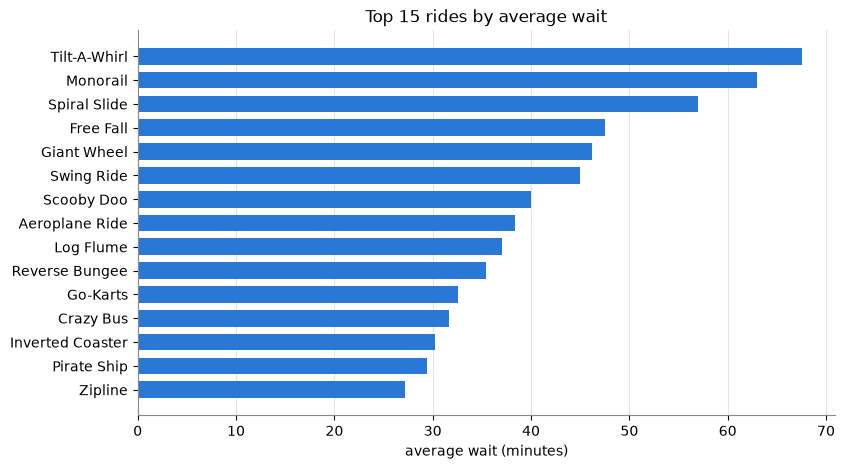

,mean,max,count
ATTRACTION,,,
Tilt-A-Whirl,67.60,300,1641
Monorail,62.90,300,52886
Spiral Slide,56.90,300,51919
Free Fall,47.60,300,47800
Giant Wheel,46.20,300,64269
Swing Ride,44.90,300,61491
Scooby Doo,40.00,300,57287
Aeroplane Ride,38.40,300,55409
Log Flume,37.00,300,56950


In [15]:
by_ride = open_.groupby("ATTRACTION")["WAIT_TIME_MAX"].agg(["mean", "max", "count"]).sort_values("mean")
top = by_ride.tail(15)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index, top["mean"], color=BLUE, height=0.7)
ax.set_title("Top 15 rides by average wait")
ax.set_xlabel("average wait (minutes)")
ax.grid(axis="y", visible=False)
plt.show()
by_ride.sort_values("mean", ascending=False).head(15).round(1)

In [16]:
w = open_["WAIT_TIME_MAX"]
print("exactly 300:", (w == 300).sum())
print("180 to 299: ", ((w >= 180) & (w < 300)).sum())
print("121 to 179: ", ((w > 120) & (w < 180)).sum())
print("\nrides with 300 values:")
print(open_[w == 300]["ATTRACTION"].value_counts().head(10))

exactly 300: 145
180 to 299:  976
121 to 179:  2352

rides with 300 values:
ATTRACTION
Reverse Bungee      13
Swing Ride          13
Spiral Slide        13
Log Flume            9
Giant Wheel          9
Go-Karts             9
Scooby Doo           8
Aeroplane Ride       7
Spinning Coaster     7
Crazy Bus            7
Name: count, dtype: int64


catching some outliers or fake data in the cell above

**Question:** a few very popular rides vs many quiet ones? That spread is what our pavilions file should mimic.

## 9. Gaps in the 15-minute slots

In [17]:
s = waits.sort_values(["ATTRACTION", "DEB_TIME"])
step = s.groupby("ATTRACTION")["DEB_TIME"].diff()
same_day = s["WORK_DATE"].eq(s.groupby("ATTRACTION")["WORK_DATE"].shift())
gap = step[same_day]
print(f"consecutive slots within a day that are exactly 15 min apart: {(gap == pd.Timedelta(minutes=15)).mean():.1%}")
print("most common gaps:")
print(gap.value_counts().head(5))

consecutive slots within a day that are exactly 15 min apart: 100.0%
most common gaps:
DEB_TIME
0 days 00:15:00    3445188
0 days 00:30:00       1190
0 days 00:45:00        206
0 days 01:00:00         33
0 days 01:15:00          5
Name: count, dtype: int64


**Question:** if many gaps aren't 15 minutes, the "wait in 30 minutes" target will lose rows.

In [18]:
dup = link[link.duplicated("ATTRACTION", keep=False)]
print("names in both parks:", len(dup))
print(dup)

print("\nunique rides overall:", waits["ATTRACTION"].nunique())
print("sum of rides per park:", waits.groupby("PARK")["ATTRACTION"].nunique().sum())

names in both parks: 0
Empty DataFrame
Columns: [ATTRACTION, PARK]
Index: []

unique rides overall: 39
sum of rides per park: 39


## 10. Summary — write your answers here

| Check | Finding | Change to `prepare_data.py`? |
|---|---|---|
| Closed slots | | |
| Wait cap (300 min) | | |
| Attendance coverage | | |
| Attendance vs wait | | |
| Load ratio vs wait | | |
| Slot gaps | | |